In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups #function downloads 20 newsgroups datasets 
from sklearn.feature_extraction.text import CountVectorizer #countvectorizer converts text to Bag of words
from sklearn.naive_bayes import MultinomialNB, BernoulliNB #for importing Naive bayes 
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [18]:
train_data = fetch_20newsgroups(
    subset = "train",
    remove = ("headers","footers","quotes")
)#for removing unnecessary contents etc.

In [20]:
test_data = fetch_20newsgroups(
    subset = "test",
    remove = ("headers","footers","quotes")
)

In [23]:

X_train_text = train_data.data # contain training documents
y_train = train_data.target #stores the corresponding catogory number

X_test_text = test_data.data #Testing documents
y_test = test_data.target #actual labels of testing documents

class_names = train_data.target_names # stores the actual catagory names insted of numbers

In [24]:
print ("Training documents : ",len(X_train_text))#for conforming the data is correctly loaded or not
print("Testing documents : ",len(X_test_text))
print("Number of classes : ",len(class_names))

Training documents :  11314
Testing documents :  7532
Number of classes :  20


In [27]:
#converting text into Numerical features
vectorizer = CountVectorizer(
    stop_words = "english",# Remove common English words such as is , are...
    min_df = 2 # keeps only words appearing in atleast 2 documents
)
X_train = vectorizer.fit_transform(X_train_text)#performs 2 operations fit() for learn the vocabulary and Transform() to convrt training documents into count vectors
X_test = vectorizer.transform(X_test_text) 

In [28]:
print("Training feature matrix : ",X_train.shape)
print("Testing feature matrix : " , X_test.shape)

Training feature matrix :  (11314, 39115)
Testing feature matrix :  (7532, 39115)


In [29]:
mnb = MultinomialNB()
mnb.fit(
    X_train,
    y_train
)
y_pred_mnb = mnb.predict(X_test)

In [31]:
binary_vectorizer = CountVectorizer(
    stop_words = "english",
    min_df = 2,
    binary = True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [32]:
bnb = BernoulliNB()
bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb = bnb.predict(
    X_test_binary
)

In [41]:
import pandas as pd

# Evaluation metrics for MultinomialNB
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_precision = precision_score(y_test, y_pred_mnb, average='weighted')
mnb_recall = recall_score(y_test, y_pred_mnb, average='weighted')
mnb_f1 = f1_score(y_test, y_pred_mnb, average='weighted')

# Evaluation metrics for BernoulliNB
bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb, average='weighted')
bnb_recall = recall_score(y_test, y_pred_bnb, average='weighted')
bnb_f1 = f1_score(y_test, y_pred_bnb, average='weighted')

# Create comparison table
results = pd.DataFrame({
    "Model": ["MultinomialNB", "BernoulliNB"],
    "Accuracy": [mnb_accuracy, bnb_accuracy],
    "Precision": [mnb_precision, bnb_precision],
    "Recall": [mnb_recall, bnb_recall],
    "F1 Score": [mnb_f1, bnb_f1]
})

# Display table
results = results.round(3)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,MultinomialNB,0.651,0.643,0.651,0.630
1,BernoulliNB,0.485,0.627,0.485,0.481


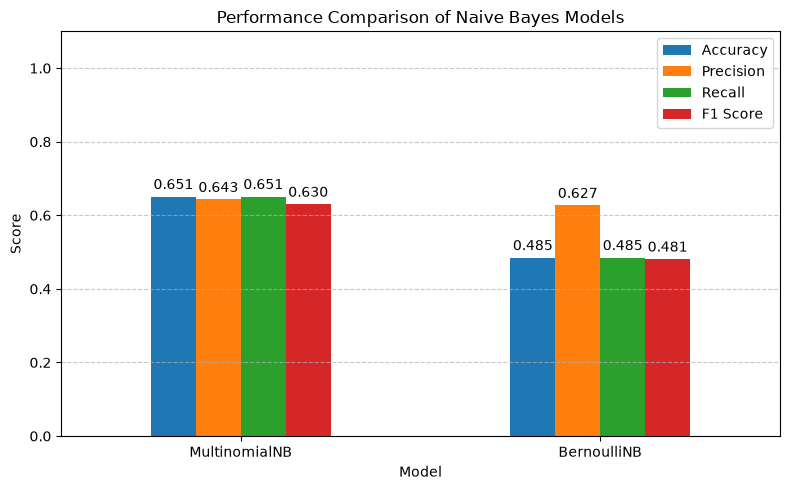

In [56]:
# Set Model as index
plot_data = results.set_index("Model")

# Plot
ax = plot_data.plot(kind='bar', figsize=(8, 5))

plt.title("Performance Comparison of Naive Bayes Models")
plt.ylabel("Score")
plt.ylim(0, 1.1)   # Increase limit to make room for labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()